# Prompt Engineering

Prompting can be critical to success.

In this section, we will:

- Present two methods for prompting: Chain of Thought (CoT) and Few-shot;
- Show you how to create prompt templates using `Jinja2`

In [47]:
from openai import OpenAI
import dotenv
import os


dotenv.load_dotenv()
HPC_API_KEY = os.getenv("HPC_API_KEY")

client = OpenAI(
    base_url='https://llm.hpc.cam.ac.uk/v1/',
    api_key=os.getenv("HPC_API_KEY")
)

## Chain-of-Thought (CoT)
Chain-of-Thought prompting has a fancy name, but it is actually very simple.

We could simply just ask the model to spit out a simple answer to a question. Below are two simple logic problems that we present to the model.

### Piaget's Glass of Water

In [48]:
user_query = (
    "Suppose I show you two glasses of water, labelled A and B. "
    "Glasses A and B appear to be identical in shape, and the water level appears "
    "to be at the same height in both glasses. "
    "I now bring out a third glass, labelled C. "
    "Glass C appears to be taller and thinner than glasses A and B. "
    "I pour the water from glass B into glass C. "
    "The water level in glass C appears to be higher than the water level in glass A. "
    "Which glass has more water, A or C? "
    "Keep your answer concise."
)

This is a classic Piaget Test. Piaget devised a series of tests for children to determine their cognitive development.

One of these tests is the prototpyical **conservation** test. Children in the **preoperational stage** of development (ages 2-7) do not have an understanding of matter conservation - they will tend to claim that the taller, thinner glass has more water in it. Children in the **concrete operational stage** (ages 7-11) do have an understanding of matter conservation, and will claim that the two glasses have the same amount of water in them. If you also said that the two glasses have the same amount of water in them, congratulations! You are at least as cognitively developed as a 7-11 year old!

In [49]:
response = client.chat.completions.create(
  model="Qwen/Qwen3.8-27B-FP8",
  messages=[
    {"role": "user", "content": user_query},
  ],
  max_tokens=512,
  temperature=0.0,
  extra_body={
      "top_k": 20,
      "chat_template_kwargs": {"enable_thinking": False},
  }, 
)

print(response.choices[0].message.content)

Glass A


Poor `Qwen`! It seems to be quite confused by this question - it is _almost_ correct, but not quite. It is not clear why this is the case, but it is clear that the model is not able to perform this task.

Try changing the model to something like `Kimi K3` though, and you will find that it **can** perform this task. Some might argue that this is a type of [emergent ability](https://arxiv.org/abs/2206.07682) - as we start adding more parameters to a model, certain behaviours and abilities unexpectedly emerge. This is a very interesting phenomenon, and it is not necessarily clear [why this happens](https://arxiv.org/abs/2307.15936), or [whether it is actually real](https://arxiv.org/abs/2304.15004) (see a rebuttal to this [here](https://www.jasonwei.net/blog/common-arguments-regarding-emergent-abilities)).

If we stick with `Qwen`, we can try to prompt the model with a CoT prompt - this has become so standard, that nowadays it's just referred to as `reasoning`. This is a prompt that is designed to elicit a series of steps from the model whereby it will generate a sort of reasoning process before coming to a conclusion. All we do is add to the end of the prompt,

```
Carefully think through the problem step by step.
```

We also make sure to keep the answer concise,

```
Keep your answer concise.
```

just to avoid the model generating an overly long-winded response.

In [50]:
user_query = (
    "Suppose I show you two glasses of water, labelled A and B. "
    "Glasses A and B appear to be identical in shape, and the water level appears "
    "to be at the same height in both glasses. "
    "I now bring out a third glass, labelled C. "
    "Glass C appears to be taller and thinner than glasses A and B. "
    "I pour the water from glass B into glass C. "
    "The water level in glass C appears to be higher than the water level in glass A. "
    "Which glass has more water, A or C? "
    "Keep your answer concise. Carefully think through the problem step by step."
)

response = client.chat.completions.create(
  model="Qwen/Qwen3.8-27B-FP8",
  messages=[
    {"role": "user", "content": user_query},
  ],
  max_tokens=512,
  temperature=0.0,
  extra_body={
      "top_k": 20,
      "chat_template_kwargs": {"enable_thinking": False},
  }, 
)

print(response.choices[0].message.content)

Glass A has more water.

**Step-by-step reasoning:**
1.  **Initial State:** Glasses A and B are identical in shape and have the same water level. Therefore, the volume of water in A equals the volume of water in B ($V_A = V_B$).
2.  **Transfer:** The water from B is poured into C. This means the volume of water in C is equal to the original volume of water in B ($V_C = V_B$).
3.  **Comparison:** Since $V_A = V_B$ and $V_C = V_B$, it logically follows that $V_A = V_C$.
4.  **Visual Illusion:** The fact that the water level in C appears higher is due to C being thinner (smaller cross-sectional area). A smaller area results in a higher height for the same volume. The visual height is a distractor; the volume remains unchanged by the container's shape.

**Conclusion:** Both glasses contain the same amount of water.


Now let's try the original prompt, but with reasoning enabled.

In [51]:
user_query = (
    "Suppose I show you two glasses of water, labelled A and B. "
    "Glasses A and B appear to be identical in shape, and the water level appears "
    "to be at the same height in both glasses. "
    "I now bring out a third glass, labelled C. "
    "Glass C appears to be taller and thinner than glasses A and B. "
    "I pour the water from glass B into glass C. "
    "The water level in glass C appears to be higher than the water level in glass A. "
    "Which glass has more water, A or C? "
    "Keep your answer concise."
)

response = client.chat.completions.create(
  model="Qwen/Qwen3.8-27B-FP8",
  messages=[
    {"role": "user", "content": user_query},
  ],
  max_tokens=512,
  temperature=0.0,
  extra_body={
      "top_k": 20,
      "chat_template_kwargs": {"enable_thinking": True},
  }, 
)

print(response.choices[0].message.model_dump())

print(response.choices[0].message.content)

{'content': 'Glass A', 'refusal': None, 'role': 'assistant', 'annotations': None, 'audio': None, 'function_call': None, 'tool_calls': None, 'provider_specific_fields': {'reasoning': None, 'refusal': None}}
Glass A


### N Lions Living in Harmony

This problem is a little harder.

In [52]:
user_query = (
    "There is an island with infinite grass and vegetation. "
    "The island is inhabited by 1 sheep and N lions. "
    "The lions can survive by eating the sheep or vegetation, "
    "but they much prefer to eat the sheep. "
    "When a lion eats the sheep, it gets converted into a sheep itself "
    "and then can in turn be eaten by other lions. "
    "The lions want to eat the sheep, but not at the risk of being eaten themselves. "
    "For which number of N will all sheep be safe? Keep your answer concise."
)

In [53]:
response = client.chat.completions.create(
  model="Qwen/Qwen3.8-27B-FP8",
  messages=[
    {"role": "user", "content": user_query},
  ],
  max_tokens=1000,
  temperature=0.0,
  extra_body={
      "top_k": 20,
      "chat_template_kwargs": {"enable_thinking": False},
  }, 
)

print(response.choices[0].message.content)

All sheep are safe when **N is even**.

**Reasoning:**
1.  If there is **1 lion** (N=1, odd), it will eat the sheep because it will become a sheep and there are no other lions left to eat it.
2.  If there are **2 lions** (N=2, even), neither will eat the sheep. If one eats the sheep, it becomes a sheep, leaving 1 lion and 1 sheep. The remaining lion will then eat the converted sheep (as per case 1). Therefore, the first lion avoids being eaten by not eating the original sheep.
3.  This logic alternates:
    *   If N is **odd**, the last lion in the chain is safe to eat, so the previous lion (facing an even number of remaining lions) is safe, and so on, leading to the first lion eating the sheep.
    *   If N is **even**, the last lion in the chain would be in a "safe to eat" position, meaning the lion before it (facing an odd number) would be eaten if it ate, so it won't eat. This safety propagates back to the first lion.

Thus, the sheep is safe if and only if **N is even**.


Depending on the model and luck, you may or may not get the right answer. To improve, try including CoT prompting, or reasoning effort.

## Few-shot prompting
When we want an LLM to do something for us, we could just ask it.

In these example, we use a selection of real and fake Haiku and ask the model to classify them as either real or fake. The fake Haiku are generated by Claude, and the real Haiku are from the famous Haiku poets [Matsuo Basho](https://en.wikipedia.org/wiki/Matsuo_Bash%C5%8D), [Yosa Buson](https://en.wikipedia.org/wiki/Yosa_Buson), and [Kobayashi Issa](https://en.wikipedia.org/wiki/Kobayashi_Issa). There are 6 each of the real poets for a total of 18, and 18 fake examples.

In [54]:
with open("haiku/real_haiku_basho.txt", "r") as f:
    real_haikus_basho = f.read().split("\n\n")

with open("haiku/real_haiku_buson.txt", "r") as f:
    real_haikus_buson = f.read().split("\n\n")

with open("haiku/real_haiku_issa.txt", "r") as f:
    real_haikus_issa = f.read().split("\n\n")

with open("haiku/gpt_haiku.txt", "r") as f:
    fake_haikus = f.read().split("\n\n")

print(real_haikus_basho[0])
print()
print(fake_haikus[0])

real_haikus = real_haikus_basho + real_haikus_buson + real_haikus_issa

all_haikus = real_haikus + fake_haikus
# 1 for real, 0 for fake
targets = [1] * len(real_haikus) + [0] * len(fake_haikus)

# shuffle
import random
zipped = list(zip(all_haikus, targets))
random.shuffle(zipped)

The old pond
a frog jumps in
sound of water

Dawn's first light
a spider weaves anew
its dew-kissed web


Some of the generated Haiku are quite similar to the original Haiku. However, what might throw off the model is that the _real_ Haiku are not necessarily in the 5-7-5 pattern (in fact most of them are not). For a very interesting analysis of influential Japanese Haiku, I strongly recommend Volume 1 of R. H. Blythe's [Haiku: Eastern Culture](https://www.amazon.co.uk/Haiku-Eastern-R-H-Blyth/dp/1621387216).

We will have to switch to `gpt-4o` to get the correct answer to this question. `gpt-4o-mini` is not able to perform this task well.

In [55]:
from tqdm import tqdm

system_prompt = (
    "You will be shown a haiku that is either written by a human or by a computer. "
    "Your job is to classify the haiku as either 'human' or 'computer'.\n\n"
    "Classify the following haiku as either written by a human or a computer. "
    "Respond with 'human' or 'computer' only."
)

result = []
for haiku, target in tqdm(zipped):
    response = client.chat.completions.create(
    model="Qwen/Qwen3.8-27B-FP8",
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": haiku},
    ],
    max_tokens=512,
    temperature=0.0,
    extra_body={
        "top_k": 20,
        "chat_template_kwargs": {"enable_thinking": False},
    }, 
    )
    result.append((haiku, target, response.choices[0].message.content))


100%|██████████| 36/36 [00:06<00:00,  5.45it/s]


In [56]:
def accuracy(result):
    correct = 0
    for haiku, target, response in result:
        if response == "human" and target == 1:
            correct += 1
        elif response == "computer" and target == 0:
            correct += 1
    return correct / len(result)

In [57]:
print(f'Accuracy: {accuracy(result)*100:.2f}%')

# print target, response
for haiku, target, response in result:
    print(target, response)

Accuracy: 38.89%
0 human
1 human
0 human
0 human
0 human
1 

human
1 human
0 human
0 

human
1 human
1 

human
0 human
1 

human
1 human
0 human
1 human
1 human
1 human
0 human
0 human
0 human
0 human
1 human
0 human
1 human
1 human
0 human
1 human
0 human
1 

human
0 human
0 human
1 human
0 human
1 human
1 human


It thinks almost all of them are human!! This is not what we want. We want the model to be able to distinguish between human and machine generated Haiku.

Let's add some examples to the prompt. We could add these into the system prompt itself, but it makes more sense to add them in the following way:

In [58]:
messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": "A cicada shell\nit sang itself\nutterly away"},
    {"role": "assistant", "content": "human"},
    {"role": "user", "content": "Crimson leaves falling\na path of quiet footsteps\nautumn fades to dusk"},
    {"role": "assistant", "content": "computer"},
    {"role": "user", "content": "It is evening autumn\nI think only\nof my parents"},
    {"role": "assistant", "content": "human"},
    {"role": "user", "content": "In the moonlit night\na distant temple bell rings\nechoes in my heart"},
    {"role": "assistant", "content": "computer"},
]

In [59]:
result = []
for haiku, target in tqdm(zipped):
    response = client.chat.completions.create(
      model="Qwen/Qwen3.8-27B-FP8",
      messages=messages + [{"role": "user", "content": haiku}],
      max_tokens=512,
      temperature=0.0,
      extra_body={
          "top_k": 20,
          "chat_template_kwargs": {"enable_thinking": False},
      }, 
    )
    result.append((haiku, target, response.choices[0].message.content))

100%|██████████| 36/36 [00:13<00:00,  2.75it/s]


In [60]:
print(f'Accuracy: {accuracy(result)*100:.2f}%')

# print target, response
for haiku, target, response in result:
    print(target, response)

Accuracy: 91.67%
0 computer
1 human
0 human
0 computer
0 computer
1 human
1 human
0 computer
0 computer
1 human
1 human
0 human
1 human
1 human
0 computer
1 human
1 computer
1 human
0 computer
0 computer
0 computer
0 computer
1 human
0 computer
1 human
1 human
0 computer
1 human
0 computer
1 human
0 computer
0 computer
1 human
0 computer
1 human
1 human


Excellent! So after just showing the model a couple of examples of each, it is now able to distinguish reasonably well between human and machine-generated Haiku. This is the power of few-shot prompting - if you can show instead of tell, you might end up with better results.

It is also possible to combine CoT and few-shot prompting. Just be aware that this may drastically increase the length of the prompt or answer.

### An aside...

We used an LLM for the above task, when we could just have easily used something else. We could have cultivated a broad dataset of real and fake Haiku and fine-tuned a BERT model for this task. More than likely, a fine-tuned BERT would have outperformed an LLM. If we only have a small amount of data, and a small amount of samples to classify an LLM will perform well. However, if we have very many potential training examples, and very many samples to classify, then using an LLM may be very expensive compared to fine-tuning a BERT model.

## General guidance for prompting

#### Be clear and specific
The model is not a mind reader. Try and avoid ambiguity in your prompts. If you are asking a question, make sure it is clear what you are asking. If you are asking for a summary, make sure it is clear what you want a summary of. If you want code, make sure you specify language, arguments, returns, etc.

#### Be concise
LLMs suffer from a retrieval bias, where they tend to favour information at the beginning and ends of prompts. A well known test for LLMs is the **needle in a haystack** test. You take a document and bury an obscure fact or sentence within it. You then ask a question related to this sentence.

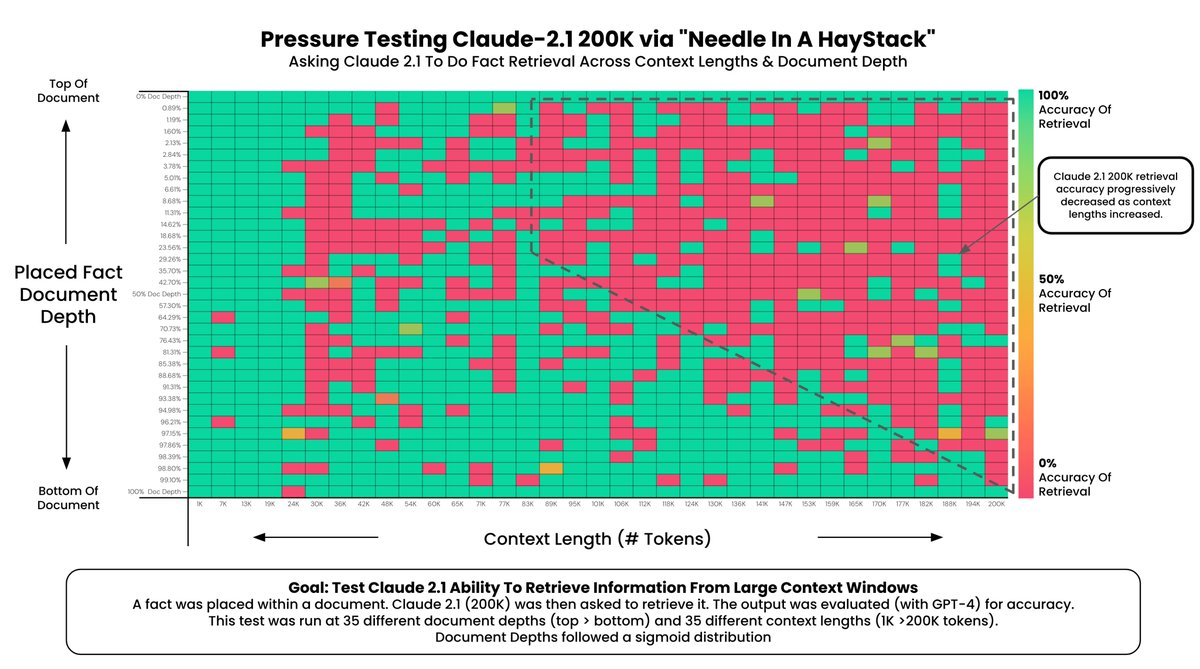

What this effectively shows is that if you make your prompt very long, and the information you are looking for is buried within it, the model may not pay close enough attention to it. Keep important information or instructions at the beginning or end of the prompt, but preferably the end. 

Note: modern LLMs are much better at this test than the one above!